<img src="https://userweb.fct.unl.pt/~jmc.xavier/MAI/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica Aplicada I 

## Força e momento de uma força
### Problema 3

Uma força vertical de 100 N é aplicada na extremidade de uma manivela fixada a um eixo em O, como se indica na figura.
Determine:


**a)** O momento da força em relação a O;

**b)** A intensidade da força horizontal aplicada em A que produz o mesmo momento;

**c)** A menor força aplicada em A que produz o mesmo momento;

**d)** A que distância do eixo deverá localizar uma força vertical de 240 N de modo a produzir o mesmo momento;

**e)** Se alguma das forças das alíneas b) a d) são equivalentes à força original.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MAI/Notebooks/Ch01/P3/MAI_Ch01_P3a.png"
width="300"/>




# Resolução

**a) O momento da força em relação a O**

O módulo do momento de uma força relativamente ao ponto $O$, é dado pelo produto 

\begin{equation*}
M = r F \sin(30) = d F 
\end{equation*}

O sentido do momento da força é definido pela regra da mão direita.

In [33]:
import numpy as np
from numpy import cos, sin, deg2rad
import matplotlib.pyplot as plt

F = 100. # unit: N
r = 0.240 # unit: m
angles_deg = [60, 30]
ang60, ang30 = [deg2rad(angulo) for angulo in angles_deg]

M = r*F*sin(ang30)
print(f'M = {M:.1f} N.m')

M = 12.0 N.m


**b) A intensidade da força horizontal aplicada em A que produz o mesmo momento**

Para calcular a força horizontal aplicada em $A$ que produz o mesmo momento da alínea a), considera-se a figura abaixo. 

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MAI/Notebooks/Ch01/P3/MAI_Ch01_P3b.png"
width="300"/>

Assim, escreve-se:

\begin{equation*}
F = \frac{M}{r  \sin(60)} = \frac{M}{d'} 
\end{equation*}

In [34]:
Fb = M/(r*sin(ang60))
print(f'F(b) = {M:.1f}/{r}/{sin(ang60):.3f} = {Fb:.1f} N.m')

F(b) = 12.0/0.24/0.866 = 57.7 N.m


**c) A menor força aplicada em A que produz o mesmo momento**

Da expressão de momento de uma força, por definição da norma do produso vetorial,

\begin{equation*}
M = rF\sin\angle(\vec{r},\vec{F})
\end{equation*}

resolvendo para F,

\begin{equation*}
F = \frac{M}{d\sin\angle(\vec{r},\vec{F})}
\end{equation*}

Assumindo $M$ e $d$ fixos, $F$ será menor quando $\sin\angle(\vec{r},\vec{F})$ for maior, ou seja, igual a 1. Logo o ângulo deve ser reto, e.i., 90 deg.

In [35]:
Fmin = M/r
print(f'Fmin = {M:.1f}/{r:.3f} = {Fmin:.1f} N')

Fmin = 12.0/0.240 = 50.0 N


**d)** A que distância do eixo deverá localizar uma força vertical de 240 N de modo a produzir o mesmo momento;

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MAI/Notebooks/Ch01/P3/MAI_Ch01_P3d.png"
width="300"/>

\begin{equation*}
M_0 = d F \quad\wedge\quad
r = \frac{d}{cos(60)}
\end{equation*}

In [36]:
F_ = 240. 
d_ = M / F_
print(f'd = {M:.1f} / {F_} =  {d_:.3f} m') 
r_ = d_ / cos(ang60)
print(f'r_ = {d_:.3f} / {cos(ang60):.1f} = {r_:.3f} m') 

d = 12.0 / 240.0 =  0.050 m
r_ = 0.050 / 0.5 = 0.100 m


    
**e)** Se alguma das forças das alíneas b) a d) são equivalentes à força original.

Para que uma força F’ seja equivalente à força original F de 100 N é preciso que tenha a mesma intensidade, direção e sentido que a força F e produza o mesmo momento (mesma linha de acção). Por conseguinte, nenhuma das forças das alíneas b) a d) são equivalentes à força de 100 N da alínea a) apesar de todas elas produzirem o mesmo momento em torno de O.


# Apêndice

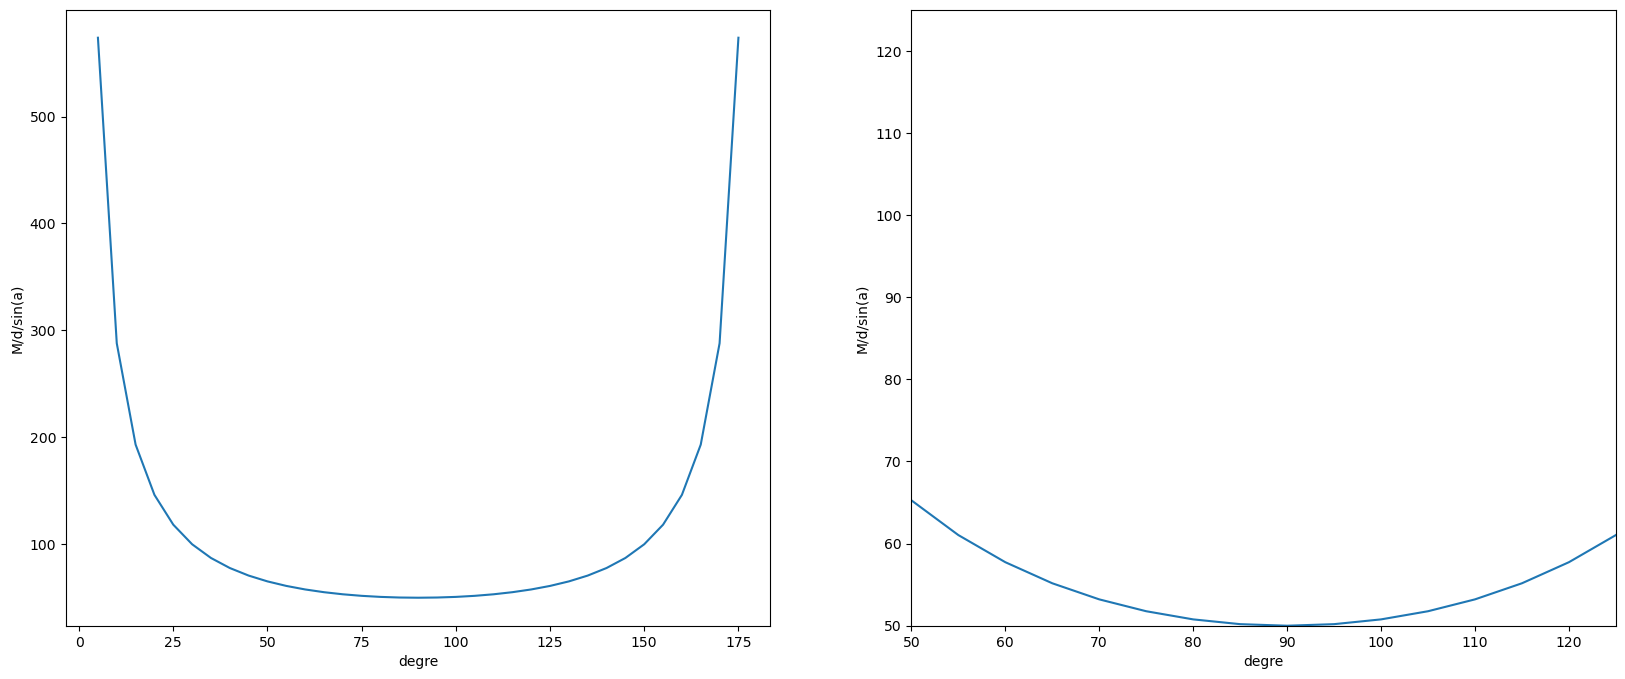

In [37]:
# Data for plotting
adeg = np.arange(5, 180, 5) # unit: deg
arad = np.deg2rad(adeg)

x = adeg
y = M/d/np.sin(arad)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(20,8))

ax1.plot(x, y)
ax1.set(xlabel='degre', ylabel='M/d/sin(a)')
plt.grid()

ax2.plot(x, y)
ax2.set(xlabel='degre', ylabel='M/d/sin(a)')
ax2.set_xlim(50,125)
ax2.set_ylim(50,125)
plt.grid()
plt.show()


Conclui-se portanto que a força mínima para produzir o mesmo momento é perpendicular ao vetor posição, para $\angle(\vec{r},\vec{F}) = 90$ deg.

In [38]:
Fmin = M/d
print(f'Fmin = {Fmin:.1f} N')

Fmin = 50.0 N


Para encontrar o ângulo entre os vetores distância e força, que minimiza a magnitude de $\vec{F}$, pode-se usar o conceito de tangente de uma função, minimização da função pela sua tangente horizontal:

\begin{equation*}
\frac{\textrm{d} F}{\textrm{d}\theta} =
\frac{\textrm{d} }{\textrm{d}\theta}
\left( \frac{M}{d\sin\theta} \right) = 0
\end{equation*}

desenvolvendo,

\begin{equation*}
-\left( \frac{M}{d} \right) \frac{\cos(\theta)}{\sin(\theta)^2} =-\left( \frac{M}{d} \right) \frac{\cot(\theta)}{\sin(\theta)} =
0
\end{equation*}


df/dth = -50.0*cos(th)/sin(th)**2


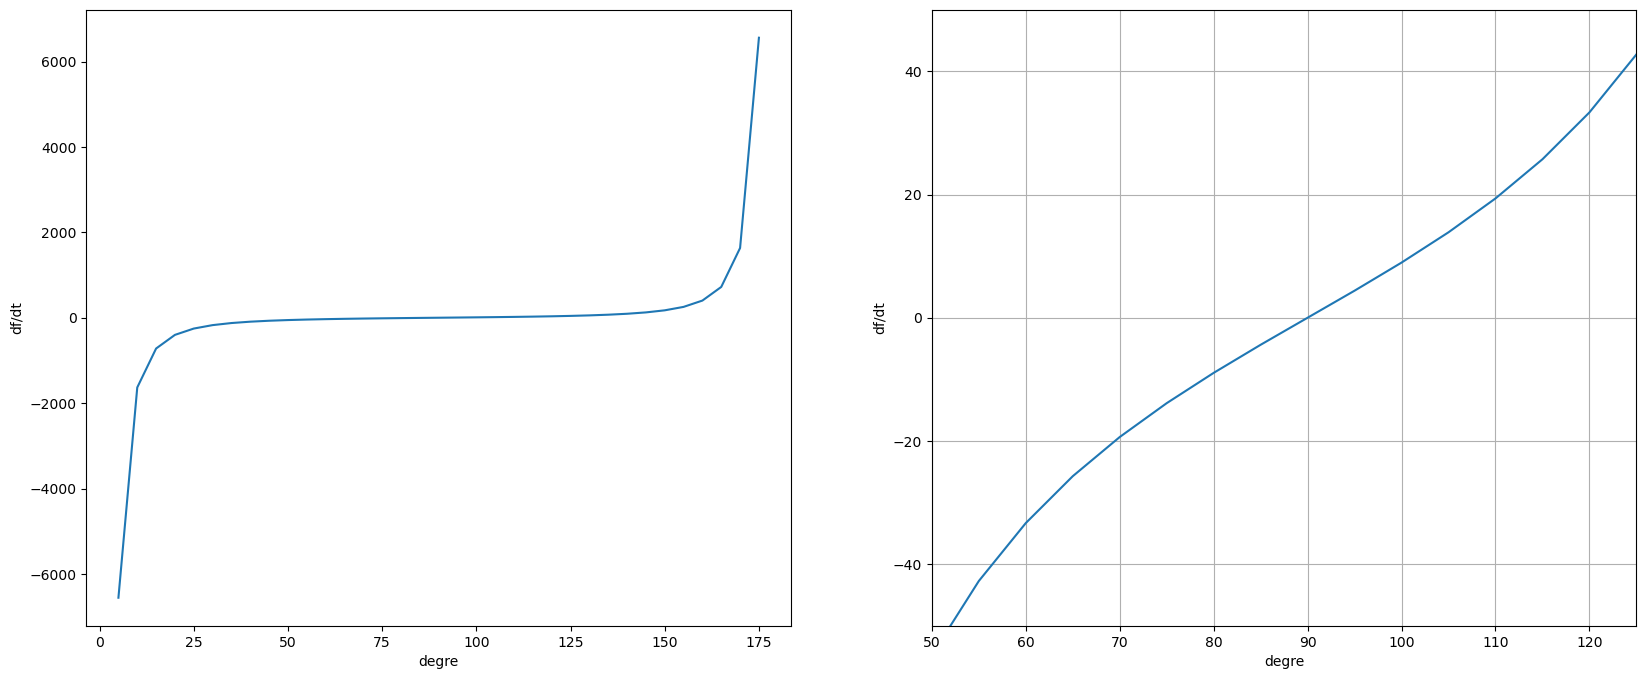

Angle = 90.0 deg


In [39]:
from sympy.solvers import solve
import sympy as sy
from sympy import diff

th = sy.symbols('th')

def f(M,d,th): return M/d/sy.sin(th)

dfdth = diff(f(M,d,th),th)
print(f'df/dth = {dfdth}')

# Function
x = adeg
j = np.zeros(np.shape(x))
k = 0
for i in x:
    j[k] = dfdth.subs(th,np.deg2rad(i))
    k += 1

fig, (ax3, ax4) = plt.subplots(1,2, figsize=(20,8))

ax3.plot(x, j)
ax3.set(xlabel='degre', ylabel='df/dt')

ax4.plot(x, j)
ax4.set(xlabel='degre', ylabel='df/dt')
ax4.set_xlim(50,125)
ax4.set_ylim(-.5e2,.5e2)
plt.grid()
plt.show()

sol = solve(dfdth,th)
print(f'Angle = {np.rad2deg(float(sol[0]))} deg')


---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>